# Faithful MID on ETH/UCY

This notebook runs the modernized reference MID implementation: the Trajectron++ social encoder plus MID's 100-step DDPM trajectory decoder. It keeps validation separate from the held-out test scene: each fold trains on `*_train.pkl`, selects `best.pt` using `*_val.pkl`, and evaluates `*_test.pkl` once.

Run order: (1) smoke test, (2) one held-out scene, (3) all five scenes, (4) comparison plot. The expensive training flags are deliberately `False` by default.

In [8]:
%cd /Users/tahaismail/Desktop/work/lyu_lab/sicnav-diffusion-reproduction

/Users/tahaismail/Desktop/work/lyu_lab/sicnav-diffusion-reproduction


In [9]:
from copy import deepcopy
from pathlib import Path
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yaml
from easydict import EasyDict

ROOT = Path.cwd().resolve()
if not (ROOT / 'trajectory_prediction' / 'MID').exists():
    raise RuntimeError('Start Jupyter from the repository root.')

MID_ROOT = ROOT / 'trajectory_prediction' / 'MID'
if str(MID_ROOT) not in sys.path:
    sys.path.insert(0, str(MID_ROOT))

from dataset import restore
from mid import MID
from utils.device import resolve_device

print('Resolved device:', resolve_device())
print('MPS built:', torch.backends.mps.is_built())
print('MPS available:', torch.backends.mps.is_available())

Resolved device: mps
MPS built: True
MPS available: True


In [14]:
CONFIG_PATH = MID_ROOT / 'configs' / 'baseline.yaml'
DATA_DIR = ROOT / 'experiments' / 'eth_ucy' / 'data'
MID_OUTPUT_DIR = ROOT / 'experiments' / 'eth_ucy' / 'outputs' / 'mid'
RESULTS_PATH = MID_OUTPUT_DIR / 'mid_all_folds_grace.csv'
SCENES = ('eth', 'hotel', 'univ', 'zara1', 'zara2')

with CONFIG_PATH.open(encoding='utf-8') as config_file:
    BASE_CONFIG = yaml.safe_load(config_file)

# Make notebook execution independent of the current working directory.
BASE_CONFIG.update({
    'data_dir': str(DATA_DIR),
    'output_dir': str(MID_OUTPUT_DIR),
    'device': 'auto',
})

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    elif torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)

def build_agent(scene, *, epochs=None, batch_size=None, offline_scene_graph=None):
    if scene not in SCENES:
        raise ValueError(f'Unknown ETH/UCY held-out scene: {scene}')
    config = deepcopy(BASE_CONFIG)
    config['dataset'] = scene
    config['exp_name'] = f'mid_{scene}'
    if epochs is not None:
        config['epochs'] = epochs
    if batch_size is not None:
        config['batch_size'] = batch_size
        config['eval_batch_size'] = batch_size
    if offline_scene_graph is not None:
        config['offline_scene_graph'] = offline_scene_graph
    seed_everything(config['seed'])
    return MID(EasyDict(config))


## One-batch smoke test

This checks the data contract before spending time training. It intentionally uses on-demand graph construction for speed; full benchmark runs use the configured offline graphs.

In [15]:
RUN_SMOKE_TEST = False

if RUN_SMOKE_TEST:
    smoke_agent = build_agent('eth', batch_size=4, offline_scene_graph=False)
    node_type = smoke_agent.train_env.NodeType.PEDESTRIAN
    edge_type = (node_type, node_type)
    smoke_batch = next(iter(smoke_agent.train_data_loader[node_type]))
    neighbor_batches = restore(smoke_batch[5])[edge_type]

    print('first_history_index:', tuple(smoke_batch[0].shape))
    print('target history x:', tuple(smoke_batch[1].shape))
    print('target future y:', tuple(smoke_batch[2].shape))
    print('neighbors per target:', [len(neighbors) for neighbors in neighbor_batches])

    smoke_agent.optimizer.zero_grad(set_to_none=True)
    smoke_loss = smoke_agent.model.get_loss(smoke_batch, 'PEDESTRIAN')
    smoke_loss.backward()
    print('epsilon MSE:', float(smoke_loss.detach()), 'on', smoke_loss.device)

    smoke_agent._set_eval_mode()
    with torch.no_grad():
        smoke_prediction = smoke_agent.model.generate(
            smoke_batch, 'PEDESTRIAN', num_points=12, sample=1, bestof=True, step=100
        )
    print('one-step generation shape:', smoke_prediction.shape)
    del smoke_agent

## One complete held-out fold

Set `RUN_SINGLE_FOLD` to `True` to train one model. The runner evaluates validation every `eval_every` epochs, saves only the lowest-validation-ADE checkpoint, reloads it, and then evaluates the held-out test split once.

In [16]:
RUN_SINGLE_FOLD = False
SINGLE_SCENE = 'eth'
SINGLE_EPOCHS = BASE_CONFIG['epochs']

single_history = None
single_result = None
if RUN_SINGLE_FOLD:
    single_agent = build_agent(SINGLE_SCENE, epochs=SINGLE_EPOCHS)
    single_history, single_result = single_agent.train()
    display(pd.DataFrame(single_history))
    display(pd.DataFrame([single_result]))

## Full leave-one-scene-out benchmark

This trains a fresh MID instance per held-out scene. It writes `mid_all_folds.csv` incrementally, so completed folds remain recorded if a longer run is interrupted.

In [18]:
RUN_ALL_FOLDS = False
ALL_FOLD_EPOCHS = BASE_CONFIG['epochs']

if RUN_ALL_FOLDS:
    MID_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    fold_results = []
    for heldout_scene in SCENES:
        print(f'\n===== MID fold: hold out {heldout_scene} =====')
        fold_agent = build_agent(heldout_scene, epochs=ALL_FOLD_EPOCHS)
        _, fold_result = fold_agent.train()
        fold_results.append(fold_result)
        pd.DataFrame(fold_results).to_csv(RESULTS_PATH, index=False)
        del fold_agent

    mid_results = pd.DataFrame(fold_results)
    display(mid_results)
else:
    mid_results = pd.read_csv(RESULTS_PATH) if RESULTS_PATH.exists() else pd.DataFrame()
    if not mid_results.empty:
        display(mid_results)

,heldout_scene,device,best_epoch,best_validation_ade_m,test_ade_m,test_fde_m,num_test_trajectories
0,eth,cuda,90,0.185341,0.432136,0.809257,364
1,hotel,cuda,90,0.191216,0.162523,0.270186,1197
2,univ,cuda,90,0.186798,0.232192,0.487758,24334
3,zara1,cuda,90,0.187049,0.191788,0.362751,2356
4,zara2,cuda,90,0.203035,0.147829,0.286727,5910


## Compare constant velocity, the toy single-agent DDPM, and MID

All values are held-out best-of-20 ADE/FDE in metres. MID uses social context; the toy DDPM and constant-velocity reference do not.

,heldout_scene,best_validation_epsilon_mse,constant_velocity_test_ade_m,constant_velocity_test_fde_m,ddpm_best_of_20_test_ade_m,ddpm_best_of_20_test_fde_m,test_ade_m,test_fde_m
0,eth,0.138466,1.075458,2.281890,1.420314,2.716869,0.432136,0.809257
1,hotel,0.140126,0.319356,0.614198,0.679565,1.396224,0.162523,0.270186
2,univ,0.142156,0.524190,1.165097,0.608148,1.178918,0.232192,0.487758
3,zara1,0.140940,0.427223,0.952377,1.234428,2.582357,0.191788,0.362751
4,zara2,0.151632,0.323937,0.724414,0.715093,1.467715,0.147829,0.286727


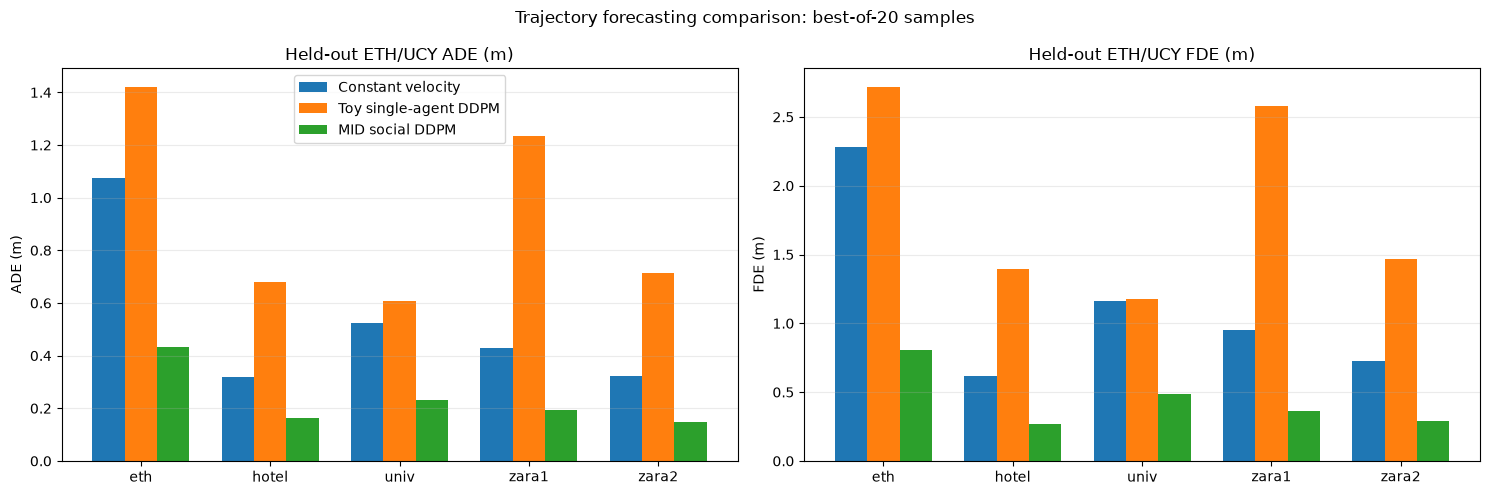

In [19]:
TOY_RESULTS_PATH = ROOT / 'experiments' / 'eth_ucy' / 'outputs' / 'single_agent_ddpm_all_folds.csv'

if not TOY_RESULTS_PATH.exists():
    raise FileNotFoundError(f'Missing toy DDPM results: {TOY_RESULTS_PATH}')
if mid_results.empty:
    print('Run one or all MID folds first; comparison will appear after mid_all_folds.csv exists.')
else:
    toy_results = pd.read_csv(TOY_RESULTS_PATH)
    comparison = toy_results.merge(
        mid_results[['heldout_scene', 'test_ade_m', 'test_fde_m']],
        on='heldout_scene', how='inner'
    ).sort_values('heldout_scene')
    display(comparison)

    plot_columns = {
        'Constant velocity': ('constant_velocity_test_ade_m', 'constant_velocity_test_fde_m'),
        'Toy single-agent DDPM': ('ddpm_best_of_20_test_ade_m', 'ddpm_best_of_20_test_fde_m'),
        'MID social DDPM': ('test_ade_m', 'test_fde_m'),
    }
    fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)
    x = np.arange(len(comparison))
    width = 0.25
    for axis, metric_index, metric_label in zip(axes, (0, 1), ('ADE (m)', 'FDE (m)')):
        for method_index, (method, columns) in enumerate(plot_columns.items()):
            axis.bar(x + (method_index - 1) * width, comparison[columns[metric_index]], width, label=method)
        axis.set_xticks(x, comparison['heldout_scene'])
        axis.set_ylabel(metric_label)
        axis.set_title(f'Held-out ETH/UCY {metric_label}')
        axis.grid(axis='y', alpha=0.25)
    axes[0].legend()
    fig.suptitle('Trajectory forecasting comparison: best-of-20 samples')
    fig.tight_layout()
    plt.show()